In [33]:
pip install -U langchain-ollama

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen2.5:3b",
    temperature=0
)

response = llm.invoke(
    "What is an AI agent?"
)

print(response.content)

An AI (Artificial Intelligence) agent is a software system designed to perceive its environment and take actions that maximize its chances of success according to some goal. These agents can be very simple, like a program that plays a single game well, or they can be complex systems capable of performing sophisticated tasks across multiple domains.

AI agents are often used in various applications such as robotics, gaming, automation, and more. They can operate autonomously or under human control, depending on the application. AI agents use algorithms and machine learning techniques to learn from experience and improve their performance over time.

In summary, an AI agent is a computational entity that exhibits intelligent behavior by understanding its environment, making decisions based on that understanding, and taking actions to achieve goals within that environment.


In [14]:
from langchain_core.tools import tool
from serpapi import GoogleSearch
import os
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from langgraph.graph import StateGraph, START, END

SERPAPI_API_KEY = os.getenv("SERPAPI_API_KEY")

In [4]:
@tool
def google_search_tool(query: str) -> list:
    """
    Search Google and return relevant web results.
    """

    search = GoogleSearch({
        "q": query,
        "api_key": SERPAPI_API_KEY,
        "engine": "google",
        "num": 5
    })

    results = search.get_dict()

    return results.get("organic_results", [])

In [5]:
llm_with_tools = llm.bind_tools(
    [google_search_tool]
)

In [6]:
response = llm_with_tools.invoke(
    """
    I need information about the latest developments
    in Retrieval-Augmented Generation.
    Search the web for relevant information.
    """
)

print(response)

content='' additional_kwargs={} response_metadata={'model': 'qwen2.5:3b', 'created_at': '2026-08-23T16:21:11.6472851Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5852041500, 'load_duration': 235373600, 'prompt_eval_count': 173, 'prompt_eval_duration': 2893026000, 'eval_count': 35, 'eval_duration': 2714914000, 'logprobs': None, 'model_name': 'qwen2.5:3b', 'model_provider': 'ollama'} id='lc_run--01a02f6c-f880-7ff2-9a64-3f53fd6052fd-0' tool_calls=[{'name': 'google_search_tool', 'args': {'query': 'latest developments in Retrieval-Augmented Generation'}, 'id': 'd4cb2904-4c79-4a39-a3f9-65114a8ff401', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 173, 'output_tokens': 35, 'total_tokens': 208}


In [10]:
class ResearchState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
def research_agent(state: ResearchState):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

In [12]:
from langgraph.prebuilt import ToolNode

tools = [
    google_search_tool
]

tool_node = ToolNode(tools)

In [13]:
def should_continue(state: ResearchState):

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return "end"

In [15]:
builder = StateGraph(ResearchState)

builder.add_node(
    "research_agent",
    research_agent
)

builder.add_node(
    "tools",
    tool_node
)

In [16]:
builder.add_edge(
    START,
    "research_agent"
)

In [17]:
builder.add_conditional_edges(
    "research_agent",
    should_continue,
    {
        "tools": "tools",
        "end": END
    }
)

In [18]:
builder.add_edge(
    "tools",
    "research_agent"
)

In [19]:
research_graph = builder.compile()

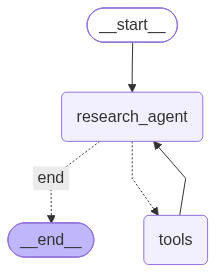

In [20]:
from IPython.display import Image, display

display(
    Image(
        research_graph
        .get_graph()
        .draw_mermaid_png()
    )
)

In [21]:
result = research_graph.invoke(
    {
        "messages": [
            (
                "user",
                "What are the latest developments in "
                "Retrieval-Augmented Generation?"
            )
        ]
    }
)

In [22]:
for message in result["messages"]:
    print("=" * 80)
    print(type(message).__name__)
    print(message.content)

    if hasattr(message, "tool_calls"):
        print("Tool calls:", message.tool_calls)

HumanMessage
What are the latest developments in Retrieval-Augmented Generation?
AIMessage

Tool calls: [{'name': 'google_search_tool', 'args': {'query': 'latest developments retrieval augmented generation'}, 'id': 'de96c6d8-8ac5-4455-970d-ae9f51db5da1', 'type': 'tool_call'}]
ToolMessage
[{"position": 1, "title": "What is RAG (Retrieval-Augmented Generation)?", "link": "https://aws.amazon.com/what-is/retrieval-augmented-generation/", "redirect_link": "https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://aws.amazon.com/what-is/retrieval-augmented-generation/&ved=2ahUKEwjShNPolbeWAxUu18kDHbGMEeMQFnoECBgQAQ", "displayed_link": "https://aws.amazon.com › ... › Generative AI", "favicon": "https://serpapi.com/images/i/iVBORw0KGgoAAAANSUhEUgAAABwAAAAcCAMAAABF0y-mAAAAflBMVEUjLz4dKjohLT0NHzFQV2FKUlwAFywnM0IaKDgzPUpWXGUVJDbq6-3i4-X29_jLzc99gogAABubnqP___9yd393fIPY2twAAAAAAB8AACK1t7ujpqsADicAFitiaHGGi5GUmJ1pb3cAFCqJjpQ8RlIuOUZDS1errrEGHC_DxslAWrmhAAAA1UlEQVR4Ad2OhWGFMBBAI0iIlh

In [34]:
from typing import TypedDict


class ResearchState(TypedDict):
    query: str
    research_results: list
    documents: list
    analysis: str
    review: dict
    summary: str

In [35]:
def research_agent(state: ResearchState):

    query = state["query"]

    search_results = google_search_tool.invoke({
        "query": query
    })

    return {
        "research_results": search_results
    }

Agent 2


In [23]:
import requests
from bs4 import BeautifulSoup

In [24]:
from langchain_core.tools import tool


@tool
def extract_webpage(url: str) -> str:
    """
    Fetch a webpage and extract its readable text.
    """

    try:
        response = requests.get(
            url,
            timeout=10,
            headers={
                "User-Agent": "Mozilla/5.0"
            }
        )

        response.raise_for_status()

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        # Remove irrelevant HTML elements
        for element in soup(
            ["script", "style", "nav", "footer", "header"]
        ):
            element.decompose()

        text = soup.get_text(
            separator=" ",
            strip=True
        )

        return text

    except Exception as e:
        return f"Extraction failed: {str(e)}"

In [27]:
url = "https://github.com/aishwaryanr/awesome-generative-ai-guide/blob/main/research_updates/rag_research_table.md"

text = extract_webpage.invoke({
    "url": url
})

print(text[:3000])

awesome-generative-ai-guide/research_updates/rag_research_table.md at main · aishwaryanr/awesome-generative-ai-guide · GitHub Skip to content You signed in with another tab or window. Reload to refresh your session. You signed out in another tab or window. Reload to refresh your session. You switched accounts on another tab or window. Reload to refresh your session. Dismiss alert aishwaryanr / awesome-generative-ai-guide Public Notifications You must be signed in to change notification settings Fork 5.9k Star 28.9k Files Expand file tree main / rag_research_table.md Copy path Blame More file actions Blame More file actions Latest commit History History History 159 lines (154 loc) · 113 KB main / rag_research_table.md Copy path Top File metadata and controls Preview Code Blame 159 lines (154 loc) · 113 KB Raw Copy raw file Download raw file Outline Edit and raw actions 🌟 Most Impactful RAG Papers (March 2023 to June 2026) The concept of Retrieval-Augmented Generation (RAG) was introduce

In [28]:
extraction_llm = llm.bind_tools(
    [extract_webpage]
)

In [29]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class ResearchState(TypedDict):
    query: str
    research_results: list
    documents: list
    analysis: str
    summary: str

In [30]:
def extraction_agent(state: ResearchState):

    research_results = state["research_results"]

    extracted_documents = []

    for result in research_results[:3]:

        url = result.get("link")

        if not url:
            continue

        content = extract_webpage.invoke({
            "url": url
        })

        extracted_documents.append({
            "title": result.get("title", ""),
            "url": url,
            "content": content
        })

    return {
        "documents": extracted_documents
    }

In [36]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ResearchState)

builder.add_node(
    "research_agent",
    research_agent
)

builder.add_node(
    "extraction_agent",
    extraction_agent
)

builder.add_edge(
    START,
    "research_agent"
)

builder.add_edge(
    "research_agent",
    "extraction_agent"
)

builder.add_edge(
    "extraction_agent",
    END
)

research_graph = builder.compile()

In [37]:
initial_state = {
    "query": "What are the latest developments in RAG?",
    "research_results": [],
    "documents": [],
    "analysis": "",
    "review": {},
    "summary": ""
}

result = research_graph.invoke(initial_state)

In [38]:
print("Research Results:")
print(result["research_results"])

Research Results:
[{'position': 1, 'title': 'People working with RAG — what changed in the last 6 ...', 'link': 'https://www.reddit.com/r/LangChain/comments/1s7lhm1/people_working_with_rag_what_changed_in_the_last/', 'redirect_link': 'https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://www.reddit.com/r/LangChain/comments/1s7lhm1/people_working_with_rag_what_changed_in_the_last/&ved=2ahUKEwjuvuOOpLeWAxUngP0HHcZ8CaAQFnoECCEQAQ', 'displayed_link': '30+ comments · 4 months ago', 'favicon': 'https://serpapi.com/images/i/iVBORw0KGgoAAAANSUhEUgAAABwAAAAcCAMAAABF0y-mAAAAhFBMVEVHcEz_RQD_RQD_RQD_RQD_RQD_RQD_RQD_RQD_PQD_NgD-XS32dlf5vK3____64dusLADUz9H-jXLOPAoSHiFrLBm3uLn3_f7jVS_b6e77pJDJo6H718__RQDw9ffs5-jm8fPIXlHqKwD5-PjolIP_VgP_SQLQ2uAyODvQ4ekABAhqcHK4ptuCAAAAHnRSTlMAPobB7P9mHdb__________________________8J6YdtgAAABWUlEQVR4AWySYZNDMBCGWyw2SI9TGnWqILT____dm6Enc-MZH8Qz2V3Je_rj7Lgekec659N_fIgPnn-yCULaYaYwsCqShYhiQXQ-dJxIedltQDZfqZQyY6K1st3vO78WsiyNDI3zySK_caJUygTMzN7eTnxdBXMcb

In [39]:
print("\nExtracted Documents:")
print(result["documents"])


Extracted Documents:
[{'title': 'People working with RAG — what changed in the last 6 ...', 'url': 'https://www.reddit.com/r/LangChain/comments/1s7lhm1/people_working_with_rag_what_changed_in_the_last/', 'content': 'Extraction failed: 403 Client Error: Blocked for url: https://www.reddit.com/r/LangChain/comments/1s7lhm1/people_working_with_rag_what_changed_in_the_last/'}, {'title': 'What is RAG? Latest Advances in Retrieval-Augmented ...', 'url': 'https://squirro.com/squirro-blog/state-of-rag-genai', 'content': "What is RAG? Latest Advances in Retrieval-Augmented Generation Skip to article Retrieval Augmented Generation (RAG) Comes of Age: Addressing Enterprise AI Challenges In the race for AI-driven transformation, many enterprises find themselves grappling with a critical paradox: how to unleash the power of LLMs without compromising data accuracy, regulatory compliance, or spiraling operational costs. Outdated insights, hallucinated outputs, and the prohibitive expense of continuou

In [43]:
for state in research_graph.stream(
    initial_state,
    stream_mode="updates"
):
    print(state)

{'research_agent': {'research_results': [{'position': 1, 'title': 'People working with RAG — what changed in the last 6 ...', 'link': 'https://www.reddit.com/r/LangChain/comments/1s7lhm1/people_working_with_rag_what_changed_in_the_last/', 'redirect_link': 'https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://www.reddit.com/r/LangChain/comments/1s7lhm1/people_working_with_rag_what_changed_in_the_last/&ved=2ahUKEwjuvuOOpLeWAxUngP0HHcZ8CaAQFnoECCEQAQ', 'displayed_link': '30+ comments · 4 months ago', 'favicon': 'https://serpapi.com/images/i/iVBORw0KGgoAAAANSUhEUgAAABwAAAAcCAMAAABF0y-mAAAAhFBMVEVHcEz_RQD_RQD_RQD_RQD_RQD_RQD_RQD_RQD_PQD_NgD-XS32dlf5vK3____64dusLADUz9H-jXLOPAoSHiFrLBm3uLn3_f7jVS_b6e77pJDJo6H718__RQDw9ffs5-jm8fPIXlHqKwD5-PjolIP_VgP_SQLQ2uAyODvQ4ekABAhqcHK4ptuCAAAAHnRSTlMAPobB7P9mHdb__________________________8J6YdtgAAABWUlEQVR4AWySYZNDMBCGWyw2SI9TGnWqILT____dm6Enc-MZH8Qz2V3Je_rj7Lgekec659N_fIgPnn-yCULaYaYwsCqShYhiQXQ-dJxIedltQDZfqZQyY6K1st3vO78WsiyNDI3zySK

Agent 1

In [44]:
from langsmith import Client

langsmith_client = Client()

In [45]:
from typing import TypedDict


class ResearchState(TypedDict):
    query: str

    research_results: list

    documents: list

    analysis: str

    review: dict

    summary: str

In [46]:
def research_agent(state: ResearchState):

    query = state["query"]

    results = google_search_tool.invoke({
        "query": query
    })

    return {
        "research_results": results
    }

Agent 2

In [47]:
def extraction_agent(state: ResearchState):

    research_results = state["research_results"]

    documents = []

    for result in research_results[:3]:

        url = result.get("link")

        if not url:
            continue

        content = extract_webpage.invoke({
            "url": url
        })

        documents.append({
            "title": result.get("title", ""),
            "url": url,
            "content": content
        })

    return {
        "documents": documents
    }

Agent 3

In [48]:
def analysis_agent(state: ResearchState):

    query = state["query"]
    documents = state["documents"]

    context_parts = []

    for doc in documents:

        context_parts.append(
            f"""
SOURCE TITLE:
{doc["title"]}

SOURCE URL:
{doc["url"]}

CONTENT:
{doc["content"]}
"""
        )

    context = "\n\n----------------\n\n".join(
        context_parts
    )

    prompt = f"""
You are an expert Research Analysis Agent.

Your task is to analyze information collected from
multiple web sources.

USER QUESTION:
{query}

SOURCES:
{context}

Analyze the sources and provide:

1. The most important facts.
2. Main findings.
3. Important trends.
4. Agreements between sources.
5. Contradictions or conflicting information.
6. Information that may be missing.

Important rules:
- Use ONLY the provided sources.
- Do not invent facts.
- Clearly distinguish facts from interpretations.
- Focus on information relevant to the user's question.
"""

    response = llm.invoke(prompt)

    return {
        "analysis": response.content
    }

langsmith

In [50]:
from langsmith import traceable

In [51]:
@traceable(
    name="Research Agent",
    run_type="chain"
)
def research_agent(state: ResearchState):

    query = state["query"]

    results = google_search_tool.invoke({
        "query": query
    })

    return {
        "research_results": results
    }

In [111]:
@traceable(
    name="Extraction Agent",
    run_type="chain"
)
def extraction_agent(state: ResearchState):

    research_results = state["research_results"]

    documents = []

    for result in research_results[:3]:

        url = result.get("link")

        if not url:
            continue

        content = extract_webpage.invoke({
            "url": url
        })

        documents.append({
            "title": result.get("title", ""),
            "url": url,
            "content": content
        })

    return {
        "documents": documents
        "iteration": state.get("iteration", 0) + 1,
    }

SyntaxError: invalid syntax (2644465654.py, line 30)

In [112]:
@traceable(
    name="Analysis Agent",
    run_type="chain"
)
def analysis_agent(state: ResearchState):

    query = state["query"]
    documents = state["documents"]

    context = "\n\n".join(
        f"""
TITLE: {doc["title"]}
URL: {doc["url"]}
CONTENT:
{doc["content"]}
"""
        for doc in documents
    )

    prompt = f"""
You are an expert Research Analysis Agent.

User Question:
{query}

Documents:
{context}

Analyze the documents.

Return:
- Key facts
- Main findings
- Trends
- Agreements
- Contradictions
- Missing information

Do not invent information.
"""

    response = llm.invoke(prompt)

    return {
        "analysis": response.content
    }

In [113]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ResearchState)

builder.add_node(
    "research_agent",
    research_agent
)

builder.add_node(
    "extraction_agent",
    extraction_agent
)

builder.add_node(
    "analysis_agent",
    analysis_agent
)

In [114]:
builder.add_edge(
    START,
    "research_agent"
)

builder.add_edge(
    "research_agent",
    "extraction_agent"
)

builder.add_edge(
    "extraction_agent",
    "analysis_agent"
)

builder.add_edge(
    "analysis_agent",
    END
)

In [115]:
research_graph = builder.compile()

In [116]:
initial_state = {
    "query": "What are the latest developments in RAG?",

    "research_results": [],

    "documents": [],

    "analysis": "",

    "review": {},

    "summary": ""
}

In [117]:
result = research_graph.invoke(
    initial_state
)

In [118]:
print("========== RESEARCH RESULTS ==========")

for result in result["research_results"]:

    print(result.get("title"))
    print(result.get("link"))
    print()

========== RESEARCH RESULTS ==========
People working with RAG — what changed in the last 6 ...
https://www.reddit.com/r/LangChain/comments/1s7lhm1/people_working_with_rag_what_changed_in_the_last/

What is RAG? Latest Advances in Retrieval-Augmented ...
https://squirro.com/squirro-blog/state-of-rag-genai

Retrieval Augmented Generation (RAG) for LLMs
https://www.promptingguide.ai/research/rag

8 Latest RAG Advancements Every Developer Should Know
https://zilliz.com/blog/8-latest-rag-advancements-every-developer-should-know

20 Advanced RAG Types to Know in 2026
https://www.turingpost.com/p/ragtypes

12 Advanced RAG Techniques: Beyond Naive Retrieval ...
https://atlan.com/know/advanced-rag-techniques/

What is RAG (Retrieval-Augmented Generation)?
https://aws.amazon.com/what-is/retrieval-augmented-generation/

Most Impactful RAG Papers
https://github.com/aishwaryanr/awesome-generative-ai-guide/blob/main/research_updates/rag_research_table.md

RAG Techniques
https://www.ibm.com/think/to

In [119]:
print("========== DOCUMENTS ==========")

for doc in result["documents"]:

    print(doc["title"])
    print(doc["url"])
    print(doc["content"][:2000])
    print()

========== DOCUMENTS ==========


KeyError: 'documents'

In [120]:
print("========== ANALYSIS ==========")

print(result["analysis"])

========== ANALYSIS ==========


KeyError: 'analysis'

In [121]:
result = research_graph.invoke(
    initial_state,
    config={
        "run_name": "Research Pipeline",
        "tags": [
            "multi-agent",
            "research",
            "qwen"
        ],
        "metadata": {
            "model": "qwen2.5:3b",
            "project": "AI Research Agent"
        }
    }
)

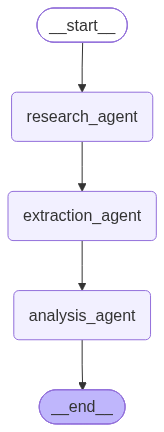

In [122]:
from IPython.display import Image, display

display(
    Image(
        research_graph
        .get_graph()
        .draw_mermaid_png()
    )
)

In [123]:
for update in research_graph.stream(
    initial_state,
    config={
        "run_name": "Research Pipeline",
        "tags": [
            "multi-agent",
            "research",
            "qwen"
        ],
        "metadata": {
            "model": "qwen2.5:3b",
            "project": "AI Research Agent"
        }
    },
    stream_mode="updates"
):
    print("=" * 80)
    print(update)

{'research_agent': {'research_results': [{'position': 1, 'title': 'People working with RAG — what changed in the last 6 ...', 'link': 'https://www.reddit.com/r/LangChain/comments/1s7lhm1/people_working_with_rag_what_changed_in_the_last/', 'redirect_link': 'https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://www.reddit.com/r/LangChain/comments/1s7lhm1/people_working_with_rag_what_changed_in_the_last/&ved=2ahUKEwj3ovDn9reWAxV_4ckDHfO7Di8QFnoECCIQAQ', 'displayed_link': '30+ comments · 4 months ago', 'favicon': 'https://serpapi.com/images/i/iVBORw0KGgoAAAANSUhEUgAAABwAAAAcCAMAAABF0y-mAAAAhFBMVEVHcEz_RQD_RQD_RQD_RQD_RQD_RQD_RQD_RQD_PQD_NgD-XS32dlf5vK3____64dusLADUz9H-jXLOPAoSHiFrLBm3uLn3_f7jVS_b6e77pJDJo6H718__RQDw9ffs5-jm8fPIXlHqKwD5-PjolIP_VgP_SQLQ2uAyODvQ4ekABAhqcHK4ptuCAAAAHnRSTlMAPobB7P9mHdb__________________________8J6YdtgAAABWUlEQVR4AWySYZNDMBCGWyw2SI9TGnWqILT____dm6Enc-MZH8Qz2V3Je_rj7Lgekec659N_fIgPnn-yCULaYaYwsCqShYhiQXQ-dJxIedltQDZfqZQyY6K1st3vO78WsiyNDI3zySK

KeyboardInterrupt: 

In [124]:
for update in research_graph.stream(
    initial_state,
    config={
        "run_name": "Research Pipeline",
        "tags": [
            "multi-agent",
            "research",
            "qwen"
        ],
        "metadata": {
            "model": "qwen2.5:3b",
            "project": "AI Research Agent"
        }
    },
    stream_mode="updates"
):
    print("=" * 80)
    print(update)

{'research_agent': {'research_results': [{'position': 1, 'title': 'People working with RAG — what changed in the last 6 ...', 'link': 'https://www.reddit.com/r/LangChain/comments/1s7lhm1/people_working_with_rag_what_changed_in_the_last/', 'redirect_link': 'https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://www.reddit.com/r/LangChain/comments/1s7lhm1/people_working_with_rag_what_changed_in_the_last/&ved=2ahUKEwj3ovDn9reWAxV_4ckDHfO7Di8QFnoECCIQAQ', 'displayed_link': '30+ comments · 4 months ago', 'favicon': 'https://serpapi.com/images/i/iVBORw0KGgoAAAANSUhEUgAAABwAAAAcCAMAAABF0y-mAAAAhFBMVEVHcEz_RQD_RQD_RQD_RQD_RQD_RQD_RQD_RQD_PQD_NgD-XS32dlf5vK3____64dusLADUz9H-jXLOPAoSHiFrLBm3uLn3_f7jVS_b6e77pJDJo6H718__RQDw9ffs5-jm8fPIXlHqKwD5-PjolIP_VgP_SQLQ2uAyODvQ4ekABAhqcHK4ptuCAAAAHnRSTlMAPobB7P9mHdb__________________________8J6YdtgAAABWUlEQVR4AWySYZNDMBCGWyw2SI9TGnWqILT____dm6Enc-MZH8Qz2V3Je_rj7Lgekec659N_fIgPnn-yCULaYaYwsCqShYhiQXQ-dJxIedltQDZfqZQyY6K1st3vO78WsiyNDI3zySK

KeyboardInterrupt: 

In [ ]:
result = research_graph.invoke(
    initial_state,
    config={
        "run_name": "Research Pipeline",
        "tags": [
            "multi-agent",
            "research",
            "qwen"
        ],
        "metadata": {
            "model": "qwen2.5:3b",
            "project": "AI Research Agent"
        }
    }
)

In [73]:
print("Research results:", len(result["research_results"]))
print("Documents:", len(result["documents"]))

print("\n========== ANALYSIS ==========\n")
print(result["analysis"])

Research results: 8
Documents: 3

========== ANALYSIS ==========

Here's an analysis based on the provided list of documents:

### Key Facts
The list covers a wide range of research and studies related to retrieval augmented language models (RAG), including pretraining strategies, techniques for improving LLM performance, and applications in various domains such as dense retrieval, knowledge-grounded dialogue generation, and zero-shot slot filling.

### Main Findings
- **Structure-Aware Language Model Pretraining**: Improves dense retrieval on structured data by leveraging the natural alignment between structured and unstructured data.
- **Prompt-Guided Retrieval Augmentation**: Enhances factual correctness of LLMs through dynamic incorporation of grounding information from heterogeneous sources in multiple domains.
- **Retrieval-Augmented Generation**: Enables models to leverage their own output (self-memory) for improved generation, reducing the need for external knowledge or pre-tra

In [125]:
for update in research_graph.stream(
    initial_state,
    config={
        "run_name": "Multi-Agent Research Pipeline",
        "tags": [
            "multi-agent",
            "research",
            "qwen"
        ],
        "metadata": {
            "model": "qwen2.5:3b",
            "project": "AI Research Agent"
        }
    },
    stream_mode="updates"
):

    print("=" * 80)

    for node_name, node_output in update.items():

        print(f"NODE: {node_name}")
        print()

        for key, value in node_output.items():

            if key == "research_results":

                print(
                    f"{key}: {len(value)} results"
                )

            elif key == "documents":

                print(
                    f"{key}: {len(value)} documents"
                )

            else:

                print(f"{key}:")
                print(value)

        print()

NODE: research_agent

research_results: 9 results

NODE: extraction_agent

documents: 3 documents

NODE: analysis_agent

analysis:
Here's an analysis based on the provided list of documents:

### Key Facts
The list covers a wide range of research and studies related to retrieval augmented language models (RAG), including pretraining strategies, techniques for improving LLM performance, and applications in various domains such as dense retrieval, knowledge-grounded dialogue generation, and zero-shot slot filling.

### Main Findings
- **Structure-Aware Language Model Pretraining**: Improves dense retrieval on structured data by leveraging the natural alignment between structured and unstructured data.
- **Prompt-Guided Retrieval Augmentation**: Enhances factual correctness of LLMs through dynamic incorporation of grounding information from heterogeneous sources in multiple domains.
- **Retrieval-Augmented Generation**: Enables models to leverage their own output (self-memory) for improve

In [126]:
from typing import Literal
from pydantic import BaseModel


class ReviewResult(BaseModel):

    decision: Literal[
        "APPROVED",
        "NEEDS_MORE"
    ]

    reason: str

    missing_information: list[str]

In [127]:
@traceable(
    name="Reviewer Agent",
    run_type="chain"
)
def reviewer_agent(state: ResearchState):

    query = state["query"]
    analysis = state["analysis"]

    prompt = f"""
You are a strict Research Reviewer.

USER QUESTION:
{query}

CURRENT ANALYSIS:
{analysis}

Your task is to determine whether the available
research is sufficient to answer the user's question.

Approve the research ONLY if:

1. The main aspects of the question are covered.
2. There is enough factual evidence.
3. Important information is not obviously missing.
4. The analysis is relevant to the question.

If important information is missing, choose NEEDS_MORE.

Return:

decision:
APPROVED or NEEDS_MORE

reason:
Explain your decision.

missing_information:
List the specific information that is missing.
"""

    structured_llm = llm.with_structured_output(
        ReviewResult
    )

    review = structured_llm.invoke(prompt)

    return {
        "review": review.model_dump()
    }

In [128]:
def review_router(state: ResearchState):

    decision = state["review"]["decision"]

    if decision == "APPROVED":
        return "summary_agent"

    return "research_agent"

In [129]:
builder.add_node(
    "reviewer_agent",
    reviewer_agent
)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [130]:
builder.add_conditional_edges(
    "reviewer_agent",
    review_router,
    {
        "summary_agent": "summary_agent",
        "research_agent": "research_agent"
    }
)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [131]:
for update in research_graph.stream(
    initial_state,
    config={
        "run_name": "Multi-Agent Research Pipeline",
        "tags": [
            "multi-agent",
            "research",
            "qwen"
        ],
        "metadata": {
            "model": "qwen2.5:3b",
            "project": "AI Research Agent"
        }
    },
    stream_mode="updates"
):

    print("=" * 80)

    for node_name, node_output in update.items():

        print(f"NODE: {node_name}")
        print()

        for key, value in node_output.items():

            if key == "research_results":

                print(
                    f"{key}: {len(value)} results"
                )

            elif key == "documents":

                print(
                    f"{key}: {len(value)} documents"
                )

            else:

                print(f"{key}:")
                print(value)

        print()

NODE: research_agent

research_results: 9 results

NODE: extraction_agent

documents: 3 documents

NODE: analysis_agent

analysis:
Here's an analysis based on the provided list of documents:

### Key Facts
The list covers a wide range of research and studies related to retrieval augmented language models (RAG), including pretraining strategies, techniques for improving LLM performance, and applications in various domains such as dense retrieval, knowledge-grounded dialogue generation, and zero-shot slot filling.

### Main Findings
- **Structure-Aware Language Model Pretraining**: Improves dense retrieval on structured data by leveraging the natural alignment between structured and unstructured data.
- **Prompt-Guided Retrieval Augmentation**: Enhances factual correctness of LLMs through dynamic incorporation of grounding information from heterogeneous sources in multiple domains.
- **Retrieval-Augmented Generation**: Enables models to leverage their own output (self-memory) for improve

In [132]:
@traceable(
    name="Research Agent",
    run_type="chain"
)
def research_agent(state: ResearchState):

    query = state["query"]
    review = state.get("review", {})
    iteration = state.get("iteration", 0)

    missing_information = review.get(
        "missing_information",
        []
    )

    if missing_information:

        search_query = (
            query
            + " "
            + " ".join(missing_information)
        )

    else:

        search_query = query

    results = google_search_tool.invoke({
        "query": search_query
    })

    return {
        "research_results": results,
        "iteration": iteration + 1
    }

In [133]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ResearchState)

builder.add_node(
    "research_agent",
    research_agent
)

builder.add_node(
    "extraction_agent",
    extraction_agent
)

builder.add_node(
    "analysis_agent",
    analysis_agent
)

builder.add_node(
    "reviewer_agent",
    reviewer_agent
)

builder.add_node(
    "summary_agent",
    summary_agent
)

In [134]:
builder.add_edge(
    START,
    "research_agent"
)

builder.add_edge(
    "research_agent",
    "extraction_agent"
)

builder.add_edge(
    "extraction_agent",
    "analysis_agent"
)

builder.add_edge(
    "analysis_agent",
    "reviewer_agent"
)

In [135]:
def review_router(state: ResearchState):

    decision = state["review"]["decision"]

    iteration = state.get("iteration", 0)  # defaults to 0 instead of crashing

    MAX_ITERATIONS = 2

    if decision == "APPROVED":

        return "summary_agent"

    if iteration >= MAX_ITERATIONS:

        return "summary_agent"

    return "research_agent"



In [136]:
builder.add_conditional_edges(
    "reviewer_agent",
    review_router,
    {
        "summary_agent": "summary_agent",
        "research_agent": "research_agent"
    }
)

In [137]:
builder.add_edge(
    "summary_agent",
    END
)

In [138]:
research_graph = builder.compile()

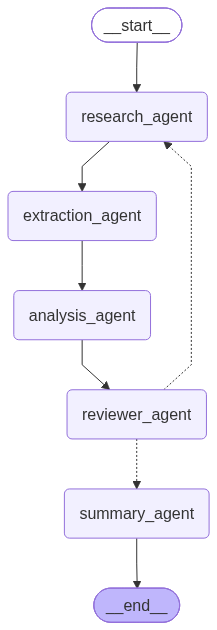

In [139]:
from IPython.display import Image, display

display(
    Image(
        research_graph
        .get_graph()
        .draw_mermaid_png()
    )
)

In [140]:
initial_state = {
    "query": "What are the latest developments in RAG?",
    "iteration": 0,
    "research_results": [],
    "documents": [],
    "analysis": "",
    "review": {},
    "summary": ""
}

In [141]:
result = research_graph.invoke(
    initial_state,
    config={
        "run_name": "Multi-Agent Research Pipeline",
        "tags": [
            "multi-agent",
            "research",
            "qwen"
        ],
        "metadata": {
            "model": "qwen2.5:3b",
            "project": "AI Research Agent"
        }
    }
)

KeyboardInterrupt: 

In [ ]:
print(result["summary"])

In [ ]:
check point

In [143]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

In [144]:
research_graph = builder.compile(
    checkpointer=checkpointer
)

In [145]:
config = {
    "configurable": {
        "thread_id": "research-session-001"
    },

    "run_name": "Multi-Agent Research Pipeline",

    "tags": [
        "multi-agent",
        "research",
        "qwen"
    ],

    "metadata": {
        "model": "qwen2.5:3b",
        "project": "AI Research Agent"
    }
}

result = research_graph.invoke(
    initial_state,
    config=config
)

KeyboardInterrupt: 

In [ ]:
snapshot = research_graph.get_state(config)
print(snapshot.values)

Dataset

In [146]:
from langsmith import Client

client = Client()

dataset = client.create_dataset(
    dataset_name="research-agent-evaluation"
)

In [147]:
client.create_examples(
    inputs=[
        {
            "query": "What is Retrieval-Augmented Generation?"
        },
        {
            "query": "What are the latest developments in RAG?"
        },
        {
            "query": "What are the advantages of Graph RAG?"
        }
    ],
    dataset_id=dataset.id
)

{'example_ids': ['2b5048af-8a61-4057-93c3-4bbc70550e9c',
  '04b89ddf-60d1-44ce-ab9a-9ec69e0996c7',
  '8e02e69b-0681-4b47-b92f-9b380bc7de8e'],
 'count': 3,
 'as_of': '2026-08-24T00:51:36.41629933Z'}

In [148]:
from pydantic import BaseModel, Field
from typing import Literal

class EvaluationResult(BaseModel):
    score: int = Field(
        description="Score from 1 to 5"
    )

    reasoning: str

evaluator_llm = llm.with_structured_output(
    EvaluationResult
)

In [149]:
def evaluate_answer(
    question: str,
    answer: str
):

    prompt = f"""
You are an evaluator.

Evaluate how well the answer addresses
the user's question.

QUESTION:
{question}

ANSWER:
{answer}

Score from 1 to 5.

5 = Excellent
4 = Good
3 = Acceptable
2 = Poor
1 = Completely irrelevant

Consider:
- Relevance
- Completeness
- Accuracy
- Clarity

Return only the structured evaluation.
"""

    result = evaluator_llm.invoke(prompt)

    return result

In [150]:
evaluation = evaluate_answer(
    initial_state["query"],
    result["summary"]
)

print(evaluation)

score=3 reasoning="The answer is marked as 'Acceptable' because it does not provide any substantive information or details about the latest developments in RAG. The response is vague and lacks specific content, which prevents a higher score."


In [151]:
class ResearchState(TypedDict):

    query: str

    research_results: list
    documents: list

    analysis: str
    review: dict

    summary: str

    iteration: int

    next_agent: str
    supervisor_reason: str

    execution_history: list

In [152]:
initial_state = {

    "query": "What are the latest developments in RAG?",

    "research_results": [],

    "documents": [],

    "analysis": "",

    "review": {},

    "summary": "",

    "iteration": 0,

    "next_agent": "",

    "supervisor_reason": "",

    "execution_history": []
}

In [153]:
def add_history(
    state: ResearchState,
    agent_name: str
):

    history = state.get(
        "execution_history",
        []
    ).copy()

    history.append(agent_name)

    return history

In [154]:
@traceable(
    name="Research Agent",
    run_type="chain"
)
def research_agent(state: ResearchState):

    query = state["query"]

    review = state.get("review", {})

    missing_information = review.get(
        "missing_information",
        []
    )

    if missing_information:

        search_query = (
            query
            + " "
            + " ".join(missing_information)
        )

    else:

        search_query = query

    results = google_search_tool.invoke({
        "query": search_query
    })

    history = add_history(
        state,
        "research_agent"
    )

    return {

        "research_results": results,

        "iteration": state["iteration"] + 1,

        "execution_history": history
    }

In [155]:
@traceable(
    name="Extraction Agent",
    run_type="chain"
)
def extraction_agent(state: ResearchState):

    research_results = state[
        "research_results"
    ]

    documents = []

    for result in research_results[:3]:

        url = result.get("link")

        if not url:
            continue

        try:

            content = extract_webpage.invoke({
                "url": url
            })

            documents.append({

                "title":
                    result.get("title", ""),

                "url":
                    url,

                "content":
                    content
            })

        except Exception as e:

            print(
                f"Extraction failed: {e}"
            )

    history = add_history(
        state,
        "extraction_agent"
    )

    return {

        "documents": documents,

        "execution_history": history
    }

In [156]:
@traceable(
    name="Analysis Agent",
    run_type="chain"
)
def analysis_agent(state: ResearchState):

    query = state["query"]

    documents = state["documents"]

    context = "\n\n".join(

        f"""
TITLE:
{doc["title"]}

URL:
{doc["url"]}

CONTENT:
{doc["content"]}
"""

        for doc in documents
    )

    prompt = f"""
You are an expert Research Analysis Agent.

USER QUESTION:
{query}

SOURCE MATERIAL:
{context}

Analyze the information.

Identify:

1. Key facts
2. Main findings
3. Important trends
4. Agreements
5. Contradictions
6. Missing information

Rules:

- Use only the provided sources.
- Do not invent facts.
- Stay focused on the question.
"""

    response = llm.invoke(
        prompt
    )

    history = add_history(
        state,
        "analysis_agent"
    )

    return {

        "analysis":
            response.content,

        "execution_history":
            history
    }

In [157]:
@traceable(
    name="Reviewer Agent",
    run_type="chain"
)
def reviewer_agent(state: ResearchState):

    query = state["query"]

    analysis = state["analysis"]

    prompt = f"""
You are a strict research reviewer.

USER QUESTION:
{query}

CURRENT ANALYSIS:
{analysis}

Determine whether the research
is sufficient to answer the question.

Approve only if:

- Important aspects are covered.
- Evidence is sufficient.
- The analysis is relevant.
- No major information is obviously missing.

Return:

decision:
APPROVED or NEEDS_MORE

reason:
Explain your decision.

missing_information:
List missing information.
"""

    structured_llm = llm.with_structured_output(
        ReviewResult
    )

    review = structured_llm.invoke(
        prompt
    )

    history = add_history(
        state,
        "reviewer_agent"
    )

    return {

        "review":
            review.model_dump(),

        "execution_history":
            history
    }

In [158]:
@traceable(
    name="Summary Agent",
    run_type="chain"
)
def summary_agent(state: ResearchState):

    query = state["query"]

    analysis = state["analysis"]

    prompt = f"""
You are a professional research summary agent.

QUESTION:
{query}

ANALYSIS:
{analysis}

Create a concise and useful final answer.

Requirements:

- Directly answer the question.
- Include the most important findings.
- Do not invent information.
- Keep it concise.
- Clearly communicate uncertainty.
"""

    response = llm.invoke(
        prompt
    )

    history = add_history(
        state,
        "summary_agent"
    )

    return {

        "summary":
            response.content,

        "execution_history":
            history
    }

In [159]:
class SupervisorDecision(BaseModel):

    next_agent: Literal[
        "research",
        "extraction",
        "analysis",
        "reviewer",
        "summary",
        "finish"
    ]

    reason: str

In [160]:
@traceable(
    name="Supervisor Agent",
    run_type="chain"
)
def supervisor_agent(state: ResearchState):

    query = state["query"]

    research_count = len(
        state["research_results"]
    )

    document_count = len(
        state["documents"]
    )

    has_analysis = bool(
        state["analysis"]
    )

    review = state["review"]

    history = state[
        "execution_history"
    ]

    iteration = state[
        "iteration"
    ]

    prompt = f"""
You are the Supervisor Agent.

You coordinate specialized agents.

You DO NOT perform research yourself.

Your job is to decide which agent
should execute next.

USER QUESTION:
{query}

CURRENT STATE:

Research results:
{research_count}

Documents:
{document_count}

Analysis available:
{has_analysis}

Review:
{review}

Execution history:
{history}

Iteration:
{iteration}

AVAILABLE AGENTS:

research:
Search for additional information.

extraction:
Extract information from research sources.

analysis:
Analyze extracted information.

reviewer:
Evaluate research quality.

summary:
Generate final answer.

finish:
End the workflow.

DECISION RULES:

1. If no research exists:
   choose research.

2. If research exists but no documents:
   choose extraction.

3. If documents exist but no analysis:
   choose analysis.

4. If analysis exists but no review:
   choose reviewer.

5. If reviewer says NEEDS_MORE:
   choose research.

6. If reviewer says APPROVED:
   choose summary.

7. If summary exists:
   choose finish.

Return only the structured decision.
"""

    structured_llm = llm.with_structured_output(
        SupervisorDecision
    )

    decision = structured_llm.invoke(
        prompt
    )

    return {

        "next_agent":
            decision.next_agent,

        "supervisor_reason":
            decision.reason
    }

In [161]:
def supervisor_router(
    state: ResearchState
):

    return state["next_agent"]

In [162]:
from langgraph.graph import (
    StateGraph,
    START,
    END
)

builder = StateGraph(
    ResearchState
)

In [163]:
builder.add_node(
    "supervisor",
    supervisor_agent
)

builder.add_node(
    "research",
    research_agent
)

builder.add_node(
    "extraction",
    extraction_agent
)

builder.add_node(
    "analysis",
    analysis_agent
)

builder.add_node(
    "reviewer",
    reviewer_agent
)

builder.add_node(
    "summary",
    summary_agent
)

In [164]:
builder.add_edge(
    "research",
    "supervisor"
)

builder.add_edge(
    "extraction",
    "supervisor"
)

builder.add_edge(
    "analysis",
    "supervisor"
)

builder.add_edge(
    "reviewer",
    "supervisor"
)

builder.add_edge(
    "summary",
    "supervisor"
)

In [165]:
builder.add_conditional_edges(

    "supervisor",

    supervisor_router,

    {

        "research":
            "research",

        "extraction":
            "extraction",

        "analysis":
            "analysis",

        "reviewer":
            "reviewer",

        "summary":
            "summary",

        "finish":
            END
    }
)

In [170]:
from langgraph.graph import StateGraph, START, END

builder.add_edge(START, "supervisor")
research_graph = builder.compile()

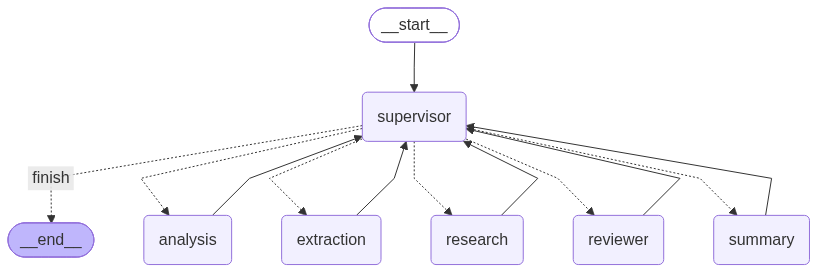

In [175]:
from IPython.display import Image, display

display(
    Image(
        research_graph
        .get_graph()
        .draw_mermaid_png()
    )
)

In [171]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

research_graph = builder.compile(
    checkpointer=checkpointer
)

In [172]:
initial_state = {

    "query":
        "What are the latest developments in RAG?",

    "research_results": [],

    "documents": [],

    "analysis": "",

    "review": {},

    "summary": "",

    "iteration": 0,

    "next_agent": "",

    "supervisor_reason": "",

    "execution_history": []
}

In [173]:
config = {

    "configurable": {
        "thread_id":
            "research-session-001"
    },

    "run_name":
        "Supervisor Multi-Agent Research",

    "tags": [
        "multi-agent",
        "supervisor",
        "research",
        "qwen"
    ],

    "metadata": {

        "model":
            "qwen2.5:3b",

        "project":
            "AI Research Agent"
    }
}

In [174]:
result = research_graph.invoke(
    initial_state,
    config=config
)


KeyboardInterrupt: 

In [1]:
print(
    result["execution_history"]
)

NameError: name 'result' is not defined

In [ ]:
supervisor_decisions: list

In [ ]:
test_state = {
    "query": "What is RAG?",
    "research_results": [],
    "documents": [],
    "analysis": "",
    "review": {},
    "summary": "",
    "iteration": 0,
    "next_agent": "",
    "supervisor_reason": "",
    "execution_history": []
}



RAG stands for Retrieval-Augmented Generation, which is an approach that combines the strengths of retrieval-based and generative models to enhance the quality and relevance of responses to queries. It uses a pre-trained language model to generate answers based on both the input query and relevant documents retrieved from a database or corpus, thereby improving the accuracy and context-awareness of the generated content.

Time: 6.31 seconds


In [180]:
start = time.time()

decision = supervisor_agent(test_state)

print(decision)
print(time.time() - start)

{'next_agent': 'research', 'supervisor_reason': 'No documents exist.'}
1.9943597316741943


In [178]:
test_state = {
    "query": "What is RAG?",
    "research_results": [],
    "documents": [],
    "analysis": "",
    "review": {},
    "summary": "",
    "iteration": 0,
    "next_agent": "",
    "supervisor_reason": "",
    "execution_history": []
}



In [179]:
start = time.time()

decision = supervisor_agent(test_state)

elapsed = time.time() - start

print(decision)
print(f"\nTime: {elapsed:.2f} seconds")

{'next_agent': 'research', 'supervisor_reason': 'No documents exist.'}

Time: 6.67 seconds
